## Genomics

Ali Powell and Luke Hakso

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable. 

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes. 

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values. 

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health? 

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('golub.csv')
df['cancer'] = df['cancer'].str.upper().str.strip()
# ALLB and ALLT are both ALL subtypes → 0; AML → 1
df['cancer'] = df['cancer'].replace({'ALLB': 0, 'ALLT': 0, 'AML': 1})
print(df['cancer'].value_counts())
df.head()

cancer
0    47
1    25
Name: count, dtype: int64


/var/folders/xj/pd7w9qz52gq4znklqy7h1rqh0000gn/T/ipykernel_75620/3641393621.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cancer'] = df['cancer'].replace({'ALLB': 0, 'ALLT': 0, 'AML': 1})


,Samples,BM.PB,Gender,Source,tissue.mf,cancer,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,39,BM,F,DFCI,BM:f,0,-1363.276427,-1058.585495,-541.469194,74.349803,...,-35.081447,1565.618803,-485.680714,-170.261227,-919.114293,1675.050053,389.769289,-526.449219,-268.963924,-779.643092
1,40,BM,F,DFCI,BM:f,0,-796.285053,-1167.103365,7.538493,83.544731,...,-404.737767,622.498054,-1275.354673,214.828233,-750.220666,-441.589276,9.841713,-671.911209,-671.911209,-644.272577
2,42,BM,F,DFCI,BM:f,0,-679.139168,-1069.832308,-690.301829,-112.075981,...,193.780934,162.525483,-692.534361,517.498108,-674.674103,1265.396405,-65.192805,-714.859684,3672.066149,-822.021231
3,47,BM,M,DFCI,BM:m,0,-1164.400197,-1109.939891,-990.127218,-238.574994,...,-256.002292,-31.625831,-621.975549,-458.594630,-630.689198,937.767618,-264.715941,-635.046022,475.944222,-794.070116
4,48,BM,F,DFCI,BM:f,0,-1299.653758,-1401.998536,-1077.543813,-437.344560,...,-509.203660,383.591216,-905.517483,-36.675640,-1116.739685,316.087213,-210.879518,-953.423549,-291.448812,-1057.945876


Training MSE: 3.361390e-30


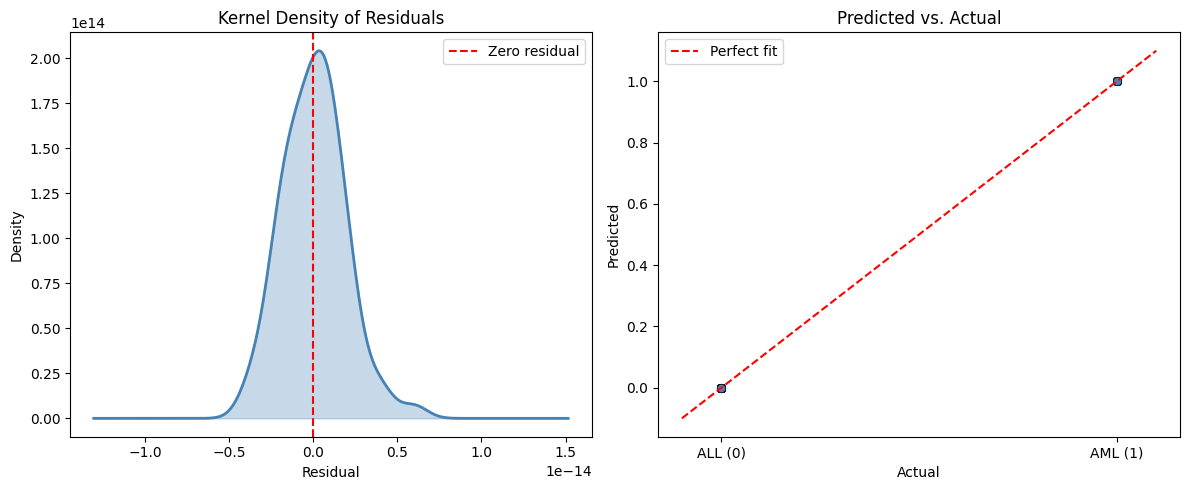

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

# Prepare features and target
gene_cols = [c for c in df.columns if c not in ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer']]
X = df[gene_cols].values.astype(float)
y = df['cancer'].values.astype(float)

# Fit linear regression
lr = LinearRegression()
lr.fit(X, y)
y_pred = lr.predict(X)

# MSE
mse = mean_squared_error(y, y_pred)
print(f"Training MSE: {mse:.6e}")

residuals = y - y_pred    

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Kernel density plot of residuals
kde = gaussian_kde(residuals)
# do padding based on std to make sure we capture the actual distribution
pad = 5 * residuals.std()                       
x_range = np.linspace(residuals.min() - pad, residuals.max() + pad, 300)  
axes[0].plot(x_range, kde(x_range), color='steelblue', lw=2)
axes[0].axvline(0, color='red', linestyle='--', label='Zero residual')
axes[0].fill_between(x_range, kde(x_range), alpha=0.3, color='steelblue')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Density')
axes[0].set_title('Kernel Density of Residuals')
axes[0].legend()

# Predicted vs Actual scatter
axes[1].scatter(y, y_pred, alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.5)
axes[1].plot([-0.1, 1.1], [-0.1, 1.1], 'r--', label='Perfect fit')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Predicted vs. Actual')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['ALL (0)', 'AML (1)'])
axes[1].legend()

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import cross_val_score

cv_mse_scores = -cross_val_score(lr, X, y, cv=5, scoring='neg_mean_squared_error')

print(f"CV MSE per fold: {cv_mse_scores}")
print(f"Mean CV MSE:     {cv_mse_scores.mean():.4f}")
print(f"Std CV MSE:      {cv_mse_scores.std():.4f}")
print(f"\nTraining MSE:    {mse:.2e}")
print(f"CV MSE is {cv_mse_scores.mean() / mse:.2e} times larger than training MSE")

CV MSE per fold: [0.04872133 0.07295289 0.04721866 0.04686773 0.08485489]
Mean CV MSE:     0.0601
Std CV MSE:      0.0158

Training MSE:    3.36e-30
CV MSE is 1.79e+28 times larger than training MSE


 With so many features, the model has low bias because it can fit the data perfectly, but it has extremely high variance (small changes in the training set lead to super different coefficients). Cross-validated MSE shows this because the model memorizes the training data and will make poor predictions on new patients.

Optimal alpha: 105.2444
Genes selected: 34
Genes discarded: 7095

Selected genes:
['HG3549-HT3751_at' 'J04164_at' 'L38941_at' 'M11147_at' 'M11722_at'
 'M17733_at' 'M19507_at' 'M26602_at' 'M27891_at' 'M33680_at' 'M63138_at'
 'M77232_rna1_at' 'M91036_rna1_at' 'M96326_rna1_at' 'U14968_at'
 'X04500_at' 'X17042_at' 'X78992_at' 'Z70759_at' 'L06797_s_at'
 'D49824_s_at' 'M25079_s_at' 'X57351_s_at' 'V00594_s_at' 'U05255_s_at'
 'X03689_s_at' 'M14328_s_at' 'M14483_rna1_s_at' 'M26708_s_at'
 'Y00787_s_at' 'Z19554_s_at' 'X56681_s_at' 'HG2887-HT3031_at'
 'M33600_f_at']


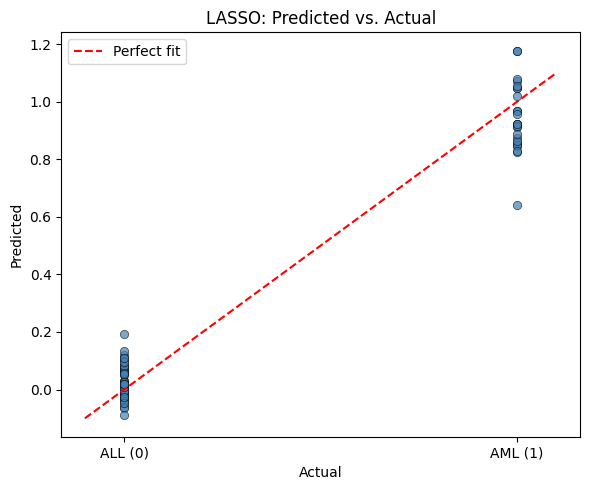

In [5]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, max_iter=10000, random_state=42)
lasso.fit(X, y)

# Selected genes (nonzero coefficients)
selected_mask = lasso.coef_ != 0
selected_genes = np.array(gene_cols)[selected_mask]
n_selected = selected_mask.sum()
n_discarded = len(gene_cols) - n_selected

print(f"Optimal alpha: {lasso.alpha_:.4f}")
print(f"Genes selected: {n_selected}")
print(f"Genes discarded: {n_discarded}")
print(f"\nSelected genes:\n{selected_genes}")

y_pred_lasso = lasso.predict(X)

plt.figure(figsize=(6, 5))
jitter = np.random.default_rng(42).uniform(-0.02, 0.02, size=len(y))
plt.scatter(y, y_pred_lasso, alpha=0.7, color='steelblue', edgecolors='k', linewidths=0.5)
plt.plot([-0.1, 1.1], [-0.1, 1.1], 'r--', label='Perfect fit')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('LASSO: Predicted vs. Actual')
plt.xticks([0, 1], ['ALL (0)', 'AML (1)'])
plt.legend()
plt.tight_layout()
plt.show()

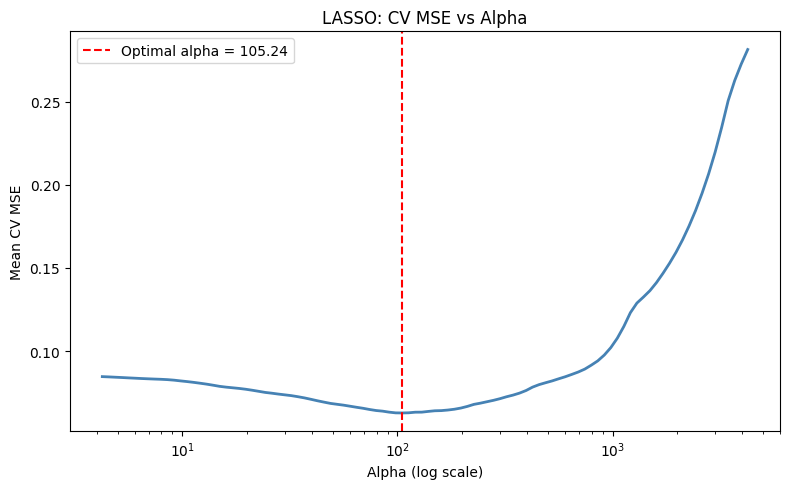

In [6]:
# 5 

alphas = lasso.alphas_
mse_path = lasso.mse_path_.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(alphas, mse_path, color='steelblue', lw=2)
plt.axvline(lasso.alpha_, color='red', linestyle='--', label=f'Optimal alpha = {lasso.alpha_:.2f}')
plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Mean CV MSE')
plt.title('LASSO: CV MSE vs Alpha')
plt.legend()
plt.tight_layout()
plt.show()

The optimal alpha is 105.24, sitting at the bottom of the curve - overfitting shown with a low alpha on the left side - when alpha is small, the penalty is weak and LASSO behaves like normal linear regression, too many genes are retained, the model memorizes the training data, and CV MSE is elevated. For underfitting (high alpha, right side), when alpha is large, (>-300) the penalty is so agressive it zeros out actually predictive genes, and CV MSE rises fast to -0.28 as the mdoel becomes too simple to capture the ALL/AML distinction. The optimal alpha here minimizes the CV MSE at around 0.06, retaining only the 34 most predictive genes and has the best balance between bias and variance. 

# 6

Linear regression has 7129 features but only 72 patients, so it can always find coefficents that fit the training data perfectly, but those coefficents are fitted to noise, not signal, and don't do well on new data. LASSO forces 7095 coefficents to zero, keeping only 34 of the most predictive genes. this introduces a small bias (training MSE isnt zero anymore) but eliminates the variance from thousands of noisy features (The result generalizes). That's what the bias variance tradeoff is, perfect training fit is worthless if it doesn't hold onto new patients. 

# 7

Precision health problems almost always have the same structure as this one, way more features than observations. You might have thousands of genes, proteins, or other metrics but only hundreds of patients. Regularization methods like LASSO are built for these sorts of cases, they automatically identify the small subset of features that actually matter and get rid of the rest, making models that generalize to new patients rather than memorizing the training sample. 

# 8

- Lasso selects genes by statistics, not biologically. A chosen gene might be correlated with a cancer type in this sample by chance, leading to interventions that target the wrong thing.
- With only 72 patients, the selected genes are very sensitive to who happened to be in the dataset, a different sample could select totally different genes.
- If treatment decisions are made based on the model, then you change the patient population, which changes future data, which again then changes the model, and the system could just become self referential
- Lasso finds predictive genes, not casual ones, and intervening on a correlated gene instead of a casual one could be ineffective or harmful.
-  if the training data isnt representative, the model might perform well for some patient groups and worse for others, leading to unequal care. 

